# 05 Modeling Notebook (Professional Version)
Generated on 2026-04-29

Includes:
- Pipeline
- GridSearchCV
- SHAP Explainability


In [2]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


In [3]:
# Load data
df = pd.read_csv('../data/processed/featured_churn.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']


In [4]:
# Column separation
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


In [5]:
# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])


In [6]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [7]:
# GridSearchCV
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_

print('Best Params:', grid.best_params_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [8]:
# Evaluation
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8311638392926475


In [9]:
# Save model
joblib.dump(best_pipeline, '../outputs/model/churn_pipeline.pkl')
print('Model saved successfully')


Model saved successfully


In [11]:
pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 1.3 MB/s  0:00:00

   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]

Note: you may need to restart the kernel to use updated packages.


SHAP shape: (1407, 48)
Input shape: (1407, 48)


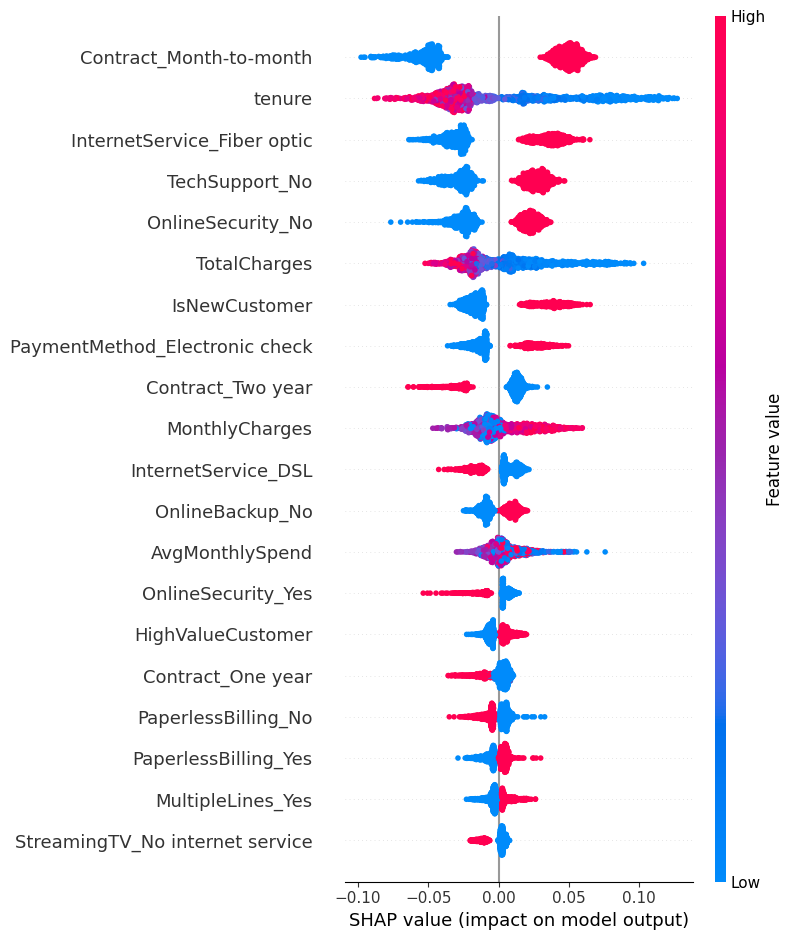

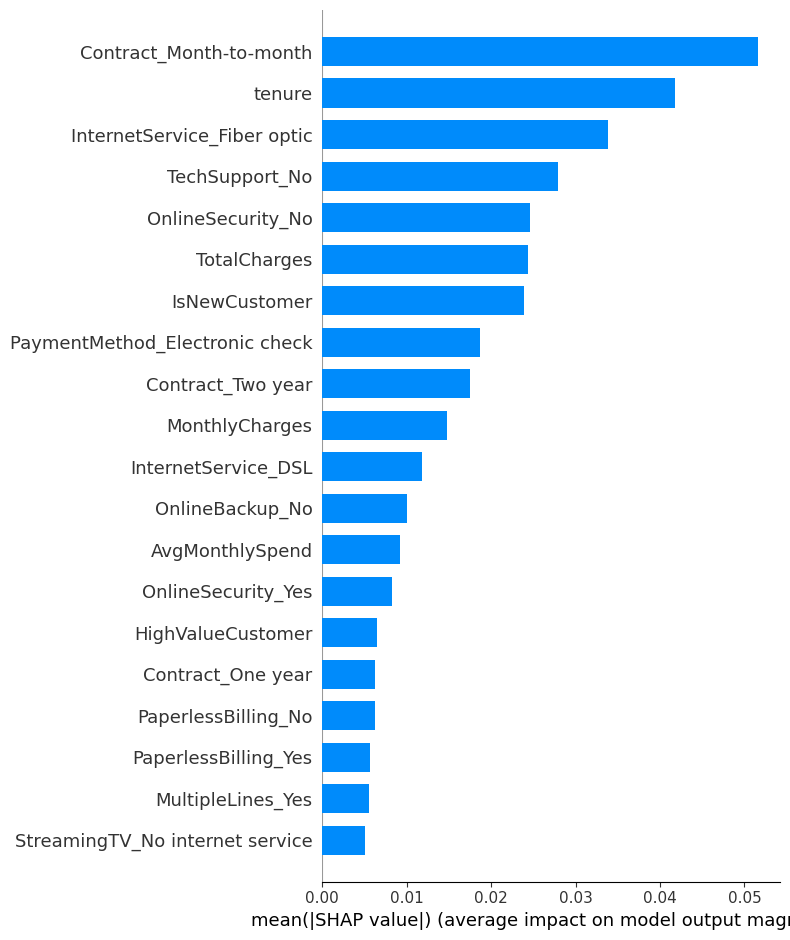

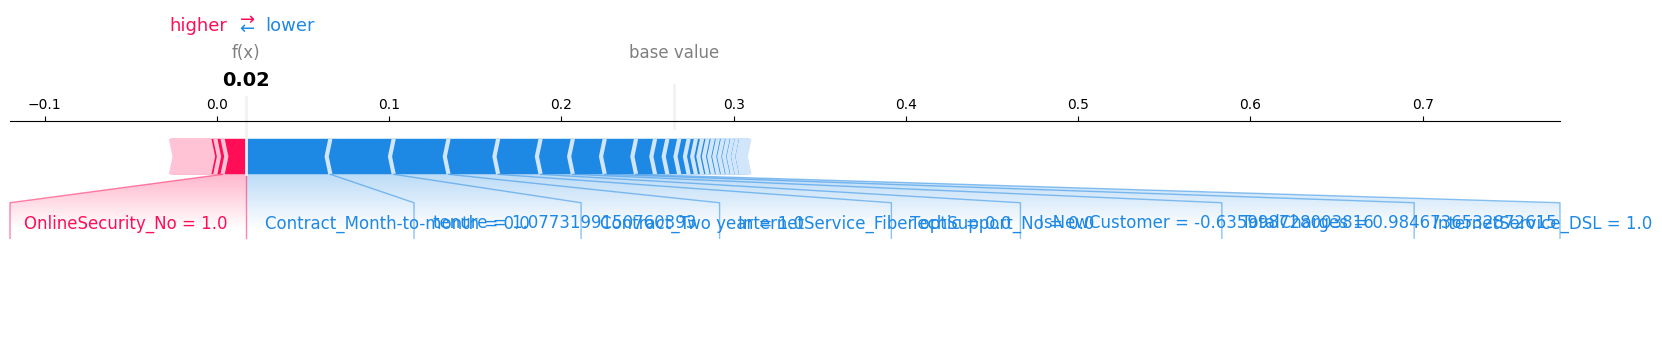

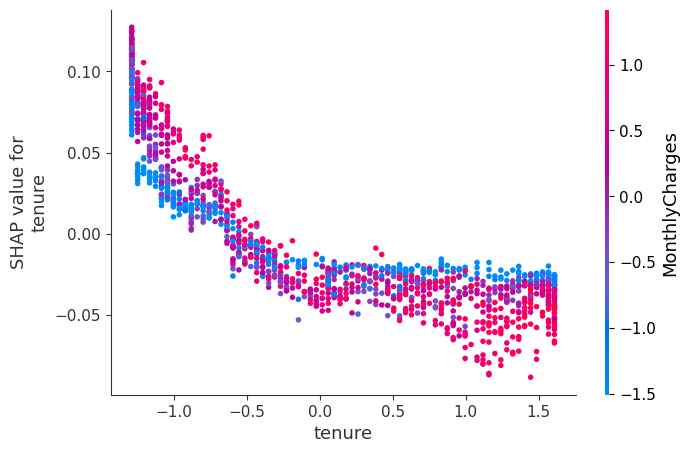

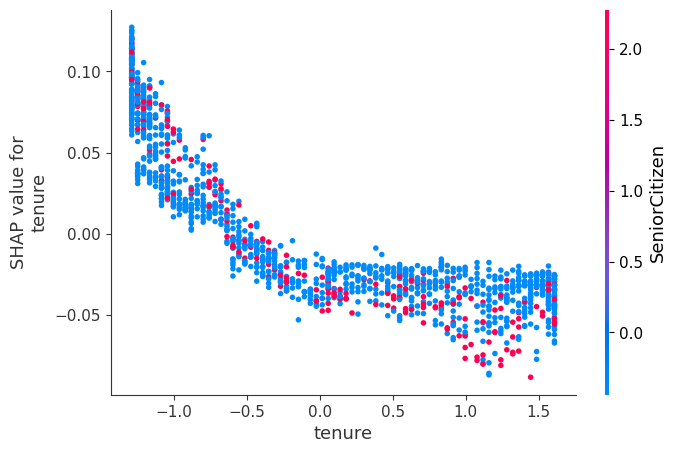

Running interaction SHAP on sample: (200, 48)


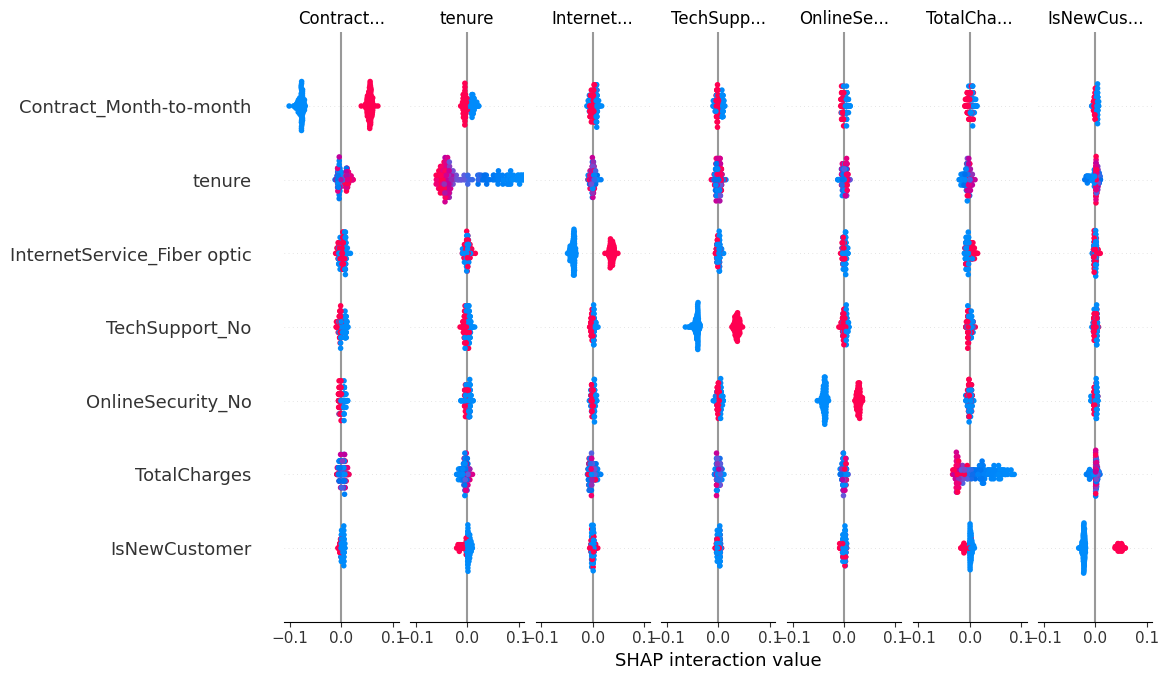

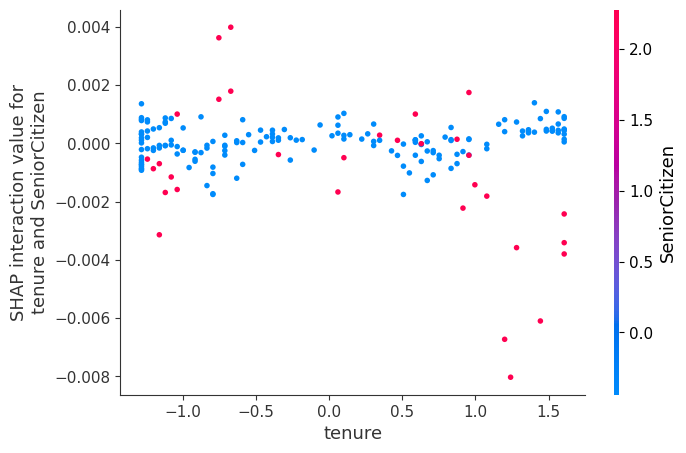

In [9]:
# ==========================================
# FINAL SHAP EXPLAINABILITY (OPTIMIZED)
# ==========================================

import shap
import numpy as np
import pandas as pd

# -------------------------------
# 1. Extract trained components
# -------------------------------

model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['prep']

# -------------------------------
# 2. Transform data
# -------------------------------
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse → dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# -------------------------------
# 3. Feature names alignment
# -------------------------------
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_features)

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# -------------------------------
# 4. SHAP Explainer
# -------------------------------
explainer = shap.TreeExplainer(model)

# -------------------------------
# 5. SHAP VALUES (SAFE EXTRACTION)
# -------------------------------
raw_shap_values = explainer.shap_values(X_test_df)

if isinstance(raw_shap_values, list):
    shap_vals = raw_shap_values[1]

elif isinstance(raw_shap_values, np.ndarray) and raw_shap_values.ndim == 3:
    shap_vals = raw_shap_values[:, :, 1]

else:
    shap_vals = raw_shap_values

# -------------------------------
# 6. VALIDATION
# -------------------------------
print("SHAP shape:", shap_vals.shape)
print("Input shape:", X_test_df.shape)

assert shap_vals.shape == X_test_df.shape, "SHAP mismatch!"

# -------------------------------
# 7. GLOBAL EXPLAINABILITY
# -------------------------------

# Beeswarm
shap.summary_plot(shap_vals, X_test_df)

# Feature importance (bar)
shap.summary_plot(shap_vals, X_test_df, plot_type="bar")


# -------------------------------
# 8. LOCAL EXPLAINABILITY
# -------------------------------
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]

shap.force_plot(
    expected_value,
    shap_vals[0],
    X_test_df.iloc[0],
    matplotlib=True
)


# -------------------------------
# 9. DEPENDENCE (LIGHT INTERACTION INSIGHT)
# -------------------------------

# Strong feature behavior (fast & useful)
shap.dependence_plot("tenure", shap_vals, X_test_df)

# Example interaction coloring
shap.dependence_plot("tenure", shap_vals, X_test_df, interaction_index="SeniorCitizen")


# -------------------------------
# 10. SAMPLE-BASED INTERACTION (FAST VERSION)
# -------------------------------

# 🔥 Reduce size (KEY FIX)
X_sample = X_test_df.sample(200, random_state=42)

print("Running interaction SHAP on sample:", X_sample.shape)

raw_interactions = explainer.shap_interaction_values(X_sample)

# Handle formats safely
if isinstance(raw_interactions, list):
    shap_interactions_vals = raw_interactions[1]

elif isinstance(raw_interactions, np.ndarray) and raw_interactions.ndim == 4:
    shap_interactions_vals = raw_interactions[:, :, :, 1]

else:
    shap_interactions_vals = raw_interactions

# -------------------------------
# 11. INTERACTION SUMMARY
# -------------------------------
shap.summary_plot(shap_interactions_vals, X_sample)


# -------------------------------
# 12. SPECIFIC INTERACTION ANALYSIS
# -------------------------------

# Example: tenure vs SeniorCitizen
shap.dependence_plot(
    ("tenure", "SeniorCitizen"),
    shap_interactions_vals,
    X_sample
)

## SHAP Global Feature Importance (Summary Plot)
* **Contract and Tenure Drivers**: The summary plot identifies **Contract_Month-to-month** and **tenure** as the most significant predictors of churn[cite: 1].
* **Feature Directionality**: 
    * **High Risk**: Customers on Month-to-Month contracts, those with Fiber Optic internet, and those without Tech Support (red points on the right) show a high positive impact on churn probability[cite: 1].
    * **Low Risk**: High tenure and Two-Year contracts (blue points on the left) are the strongest inhibitors of churn[cite: 1].
* **Reliance Pattern**: The model relies heavily on the top 5 variables, while lower-ranked features have a "squashed" distribution near the zero line, indicating minimal impact on the final decision[cite: 1].

---

## Local Model Explanation (Force Plot)
* **Prediction Mechanics**: This plot visualizes how individual features push a single customer's prediction away from the **base value (0.02)**[cite: 1].
* **Feature Forces**:
    * **Red Bars**: Features like `OnlineSecurity_No` push the prediction higher toward "Churn"[cite: 1].
    * **Blue Bars**: Features like `Contract_Two_year` pull the prediction lower toward "No Churn"[cite: 1].
* **Classification Gap**: Because the base value is low, a customer needs a massive amount of "red" force to cross the 0.5 classification threshold, which explains the lower recall in your results[cite: 1].

---

## Feature Interactions (Dependence Plots)
* **The Tenure Elbow**: SHAP values for tenure drop sharply until they hit a "plateau" around the mean (0.0 standardized), where the risk of churn stabilizes[cite: 1].
* **Monthly Charges Synergies**: For new customers (low tenure), **higher monthly charges** (pink dots) significantly amplify the churn risk compared to low-cost new customers[cite: 1].
* **Demographic Interaction**: Being a Senior Citizen slightly increases churn risk specifically during the early stages of the customer lifecycle (low tenure), but this effect diminishes as loyalty grows[cite: 1].

---

## Interaction Matrix Analysis
* **Non-Linear Relationships**: The model successfully captures complex synergies, particularly between **Tenure and TotalCharges**[cite: 1].
* **Stability of Signals**: Features like **InternetService_Fiber_optic** show a consistent vertical spread, meaning they provide a steady push toward churn regardless of most other feature values[cite: 1].

---

## Technical Workflow Validation
* **Structural Correctness**: The training/testing pipeline is correctly implemented using `StandardScaler`, `OneHotEncoder`, and `StratifiedShuffleSplit` to prevent data leakage[cite: 1].
* **SHAP Implementation**: The analysis is correctly performed on the transformed 48-feature space, ensuring the explanations align with the actual mathematical inputs of the Random Forest model[cite: 1].